This notebook focuses on trying to find a way to segment cells within organoids properly.
The end goals is to segment cell and extract morphology features from cellprofiler.
These masks must be imported into cellprofiler to extract features.

In [1]:
import argparse
import pathlib
import sys

import matplotlib.pyplot as plt

# Import dependencies
import numpy as np
import skimage
import tifffile
import torch
import tqdm
from cellpose import core, models
from cellpose.io import imread
from PIL import Image
from skimage import io

use_GPU = torch.cuda.is_available()

# set import path
sys.path.append(str(pathlib.Path("../../utils/").resolve()))

# check if in a jupyter notebook
try:
    cfg = get_ipython().config
    in_notebook = True
except NameError:
    in_notebook = False

print(in_notebook)

True


In [2]:
if not in_notebook:
    # set up arg parser
    parser = argparse.ArgumentParser(description="Segment the nuclei of a tiff image")

    parser.add_argument(
        "--patient",
        type=str,
        help="Patient ID to use for the segmentation",
    )

    parser.add_argument(
        "--well_fov",
        type=str,
        help="Path to the input directory containing the tiff images",
    )
    parser.add_argument(
        "--window_size", type=int, help="Size of the window to use for the segmentation"
    )
    parser.add_argument(
        "--clip_limit",
        type=float,
        help="Clip limit for the adaptive histogram equalization",
    )

    args = parser.parse_args()
    window_size = args.window_size
    clip_limit = args.clip_limit
    well_fov = args.well_fov
    patient = args.patient

else:
    well_fov = "C4-2"
    window_size = 3
    clip_limit = 0.1
    patient = "NF0014"


input_dir = pathlib.Path(f"../../data/{patient}/zstack_images/{well_fov}").resolve(
    strict=True
)

mask_path = pathlib.Path(f"../../data/{patient}/processed_data/{well_fov}").resolve()
mask_path.mkdir(exist_ok=True, parents=True)

## Set up images, paths and functions

In [3]:
image_extensions = {".tif", ".tiff"}
files = sorted(input_dir.glob("*"))
files = [str(x) for x in files if x.suffix in image_extensions]
masks = sorted(mask_path.glob("*"))
masks = [str(x) for x in masks if x.suffix in image_extensions]

In [4]:
# find the cytoplasmic channels in the image set
for f in files:
    if "405" in f:
        nuclei = io.imread(f)
    elif "488" in f:
        cyto1 = io.imread(f)
    elif "555" in f:
        cyto2 = io.imread(f)
    elif "640" in f:
        cyto3 = io.imread(f)
    else:
        print(f"Unknown channel: {f}")

for m in masks:
    if "nuclei_masks_reconstructed" in m:
        nuclei = io.imread(m)
    else:
        pass

# pick which channels to use for cellpose
cyto = skimage.exposure.equalize_adapthist(cyto2, clip_limit=clip_limit)


original_nuclei_image = nuclei.copy()
original_cyto_image = cyto.copy()

original_nuclei_z_count = nuclei.shape[0]
original_cyto_z_count = cyto.shape[0]

Unknown channel: /home/lippincm/Documents/GFF_3D_organoid_profiling_pipeline/data/NF0014/zstack_images/C4-2/C4-2_TRANS.tif


In [5]:
# make a 2.5 D max projection image stack with a sliding window of 3 slices
image_stack_2_5D = np.empty((0, cyto.shape[1], cyto.shape[2]), dtype=cyto.dtype)
for image_index in range(cyto.shape[0]):
    image_stack_window = cyto[image_index : image_index + window_size]
    if not image_stack_window.shape[0] == window_size:
        break
    # max project the image stack
    image_stack_2_5D = np.append(
        image_stack_2_5D, np.max(image_stack_window, axis=0)[np.newaxis, :, :], axis=0
    )

image_stack_2_5D = np.array(image_stack_2_5D)
cyto = np.array(image_stack_2_5D)
print("2.5D cyto image stack shape:", cyto.shape)


# make a 2.5 D max projection image stack with a sliding window of 3 slices
image_stack_2_5D = np.empty((0, nuclei.shape[1], nuclei.shape[2]), dtype=nuclei.dtype)
for image_index in range(nuclei.shape[0]):
    image_stack_window = nuclei[image_index : image_index + window_size]
    if not image_stack_window.shape[0] == window_size:
        break
    # max project the image stack
    image_stack_2_5D = np.append(
        image_stack_2_5D, np.max(image_stack_window, axis=0)[np.newaxis, :, :], axis=0
    )

nuclei = np.array(image_stack_2_5D)
print("2.5D nuclei image stack shape:", nuclei.shape)

2.5D cyto image stack shape: (31, 1537, 1540)
2.5D nuclei image stack shape: (31, 1537, 1540)


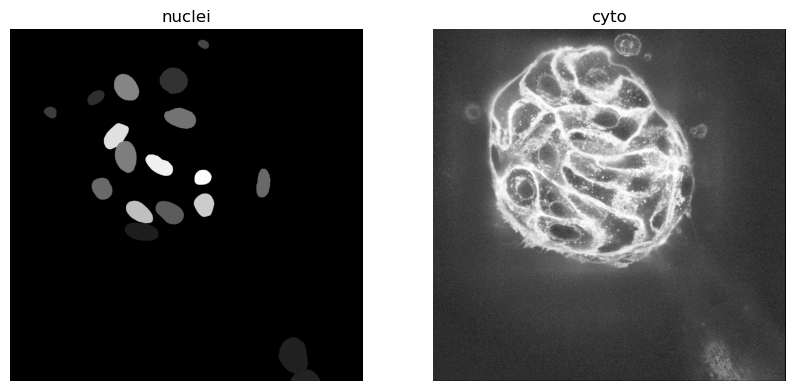

In [6]:
if in_notebook:
    # plot the nuclei and the cyto channels
    plt.figure(figsize=(10, 10))
    plt.subplot(121)
    plt.imshow(nuclei[2, :, :], cmap="gray")
    plt.title("nuclei")
    plt.axis("off")
    plt.subplot(122)
    plt.imshow(cyto[2, :, :], cmap="gray")
    plt.title("cyto")
    plt.axis("off")
    plt.show()

In [7]:
imgs = []
# save each z-slice as an RGB png
for z in range(nuclei.shape[0]):
    nuclei_tmp = nuclei[z, :, :]
    cyto_tmp = cyto[z, :, :]
    nuclei_tmp = (nuclei_tmp / nuclei_tmp.max() * 255).astype(np.uint8)
    cyto_tmp = (cyto_tmp / cyto_tmp.max() * 255).astype(np.uint8)
    # save the image as an RGB png with nuclei in blue and cytoplasm in red
    RGB = np.stack([cyto_tmp, np.zeros_like(cyto_tmp), nuclei_tmp], axis=-1)

    # change to 8-bit
    RGB = (RGB / RGB.max() * 255).astype(np.uint8)

    rgb_image_pil = Image.fromarray(RGB)

    imgs.append(rgb_image_pil)

## Cellpose

In [8]:
# model_type='cyto' or 'nuclei' or 'cyto2' or 'cyto3'
model_name = "cyto3"
model = models.Cellpose(model_type=model_name, gpu=use_GPU)

channels = [[1, 3]]  # channels=[red cells, blue nuclei]
diameter = 200

masks_all_dict = {"masks": [], "imgs": []}
imgs = np.array(imgs)

# get masks for all the images
# save to a dict for later use
for img in tqdm.tqdm(imgs):
    masks, flows, styles, diams = model.eval(img, diameter=diameter, channels=channels)
    masks_all_dict["masks"].append(masks)
    masks_all_dict["imgs"].append(img)
print(len(masks_all_dict))

100%|██████████| 31/31 [00:35<00:00,  1.15s/it]

2


In [9]:
masks_all = masks_all_dict["masks"]
imgs = masks_all_dict["imgs"]

In [10]:
# reverse sliding window max projection
full_mask_z_stack = []
reconstruction_dict = {index: [] for index in range(original_cyto_z_count)}
print(
    f"Decoupling {len(masks_all)} max slices with the sliding window max projection of {window_size} slices"
)

# decouple the sliding window max projection based on window size
# each slice in a stack
for z_stack_mask_index in range(len(masks_all)):
    # temoporary list to hold the decoupled z stack
    z_stack_decouple = []
    # decouple
    [z_stack_decouple.append(masks_all[z_stack_mask_index]) for _ in range(window_size)]
    # dull out the decouple slice to the correct z index
    for z_window_index, z_stack_mask in enumerate(z_stack_decouple):
        if not (z_stack_mask_index + z_window_index) >= original_cyto_z_count:
            reconstruction_dict[z_stack_mask_index + z_window_index].append(
                z_stack_mask
            )
print(f"Saving the decoupled masks of size {len(reconstruction_dict)}")
# save the reconstruction_dict to a file for downstream decoupling
np.save(mask_path / "cell_reconstruction_dict.npy", reconstruction_dict)

Decoupling 31 max slices with the sliding window max projection of 3 slices
Saving the decoupled masks of size 33


<Figure size 1000x500 with 0 Axes>

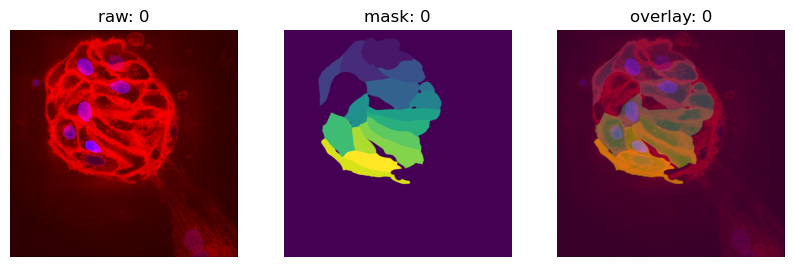

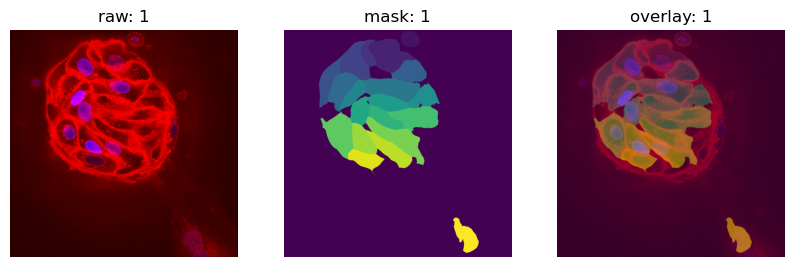

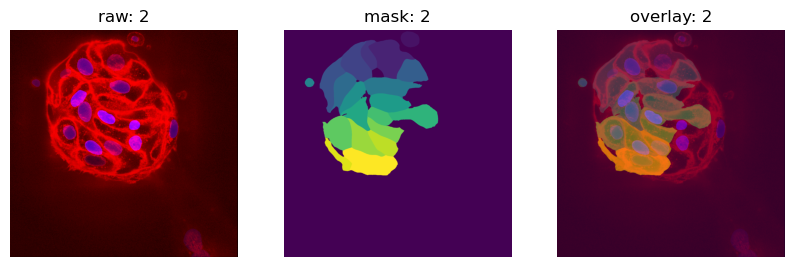

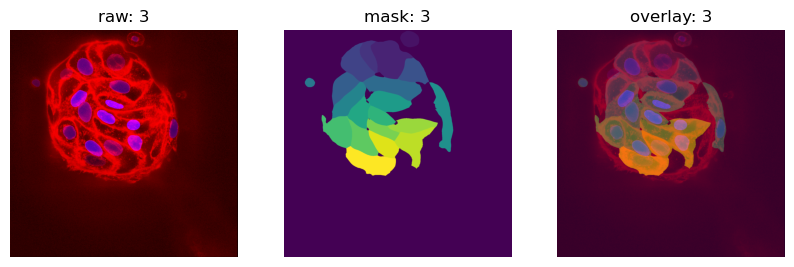

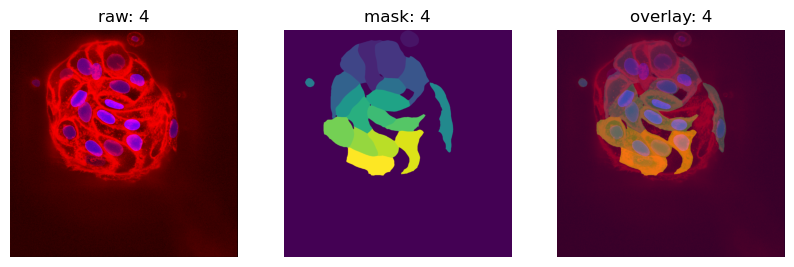

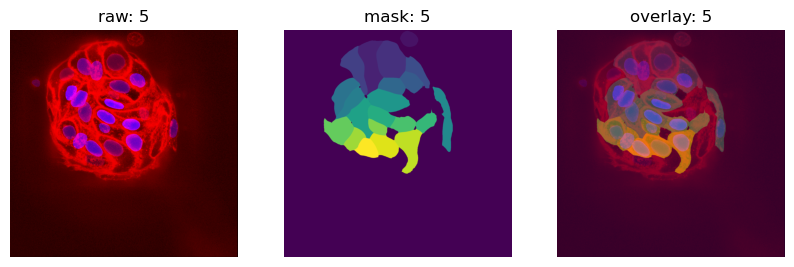

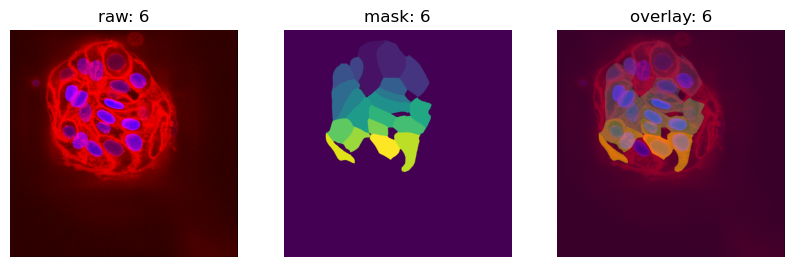

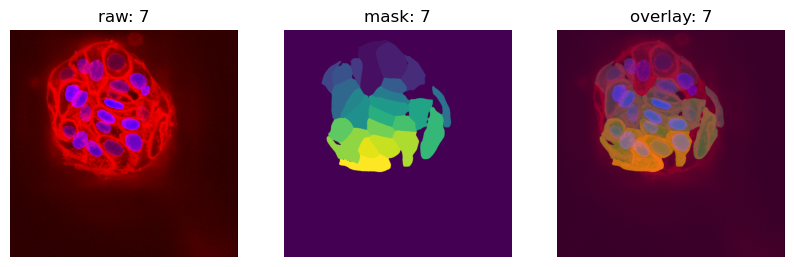

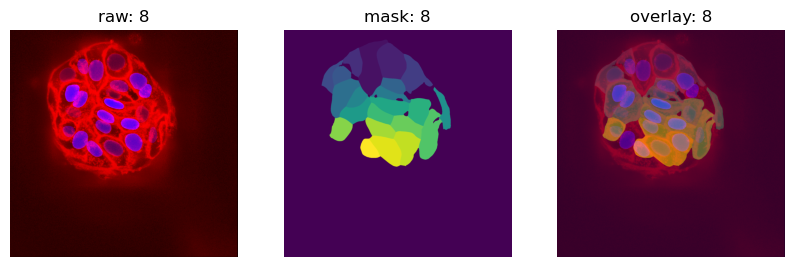

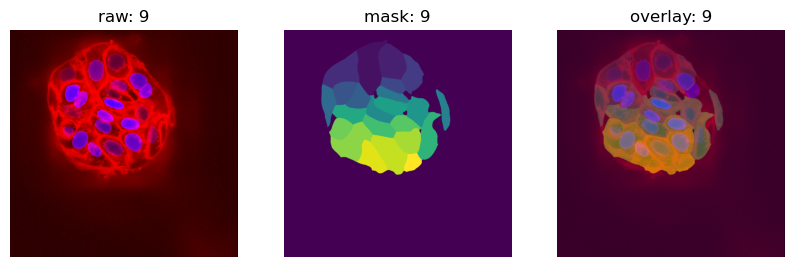

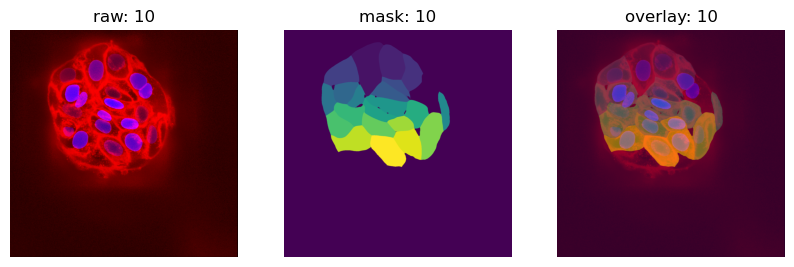

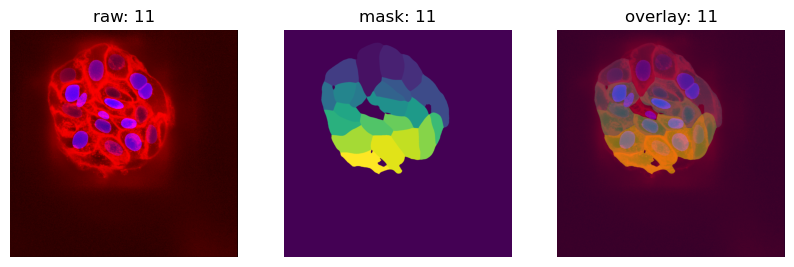

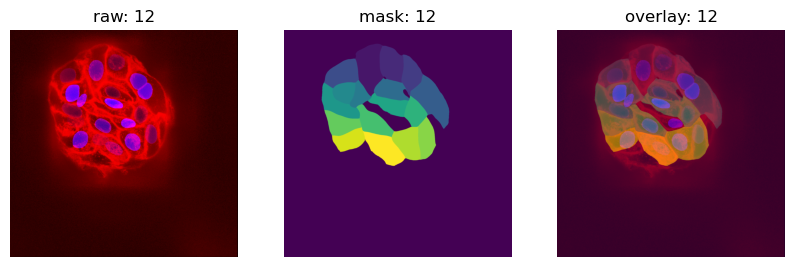

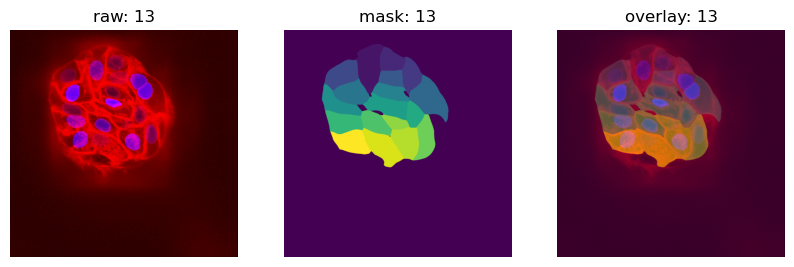

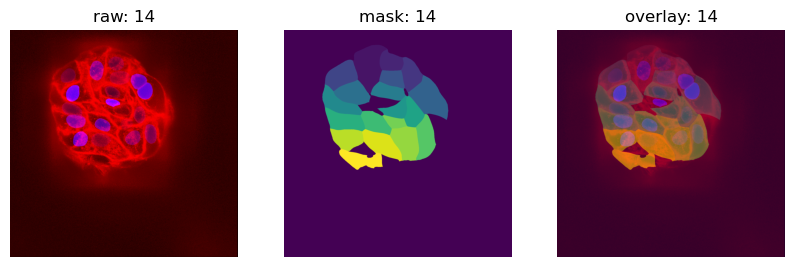

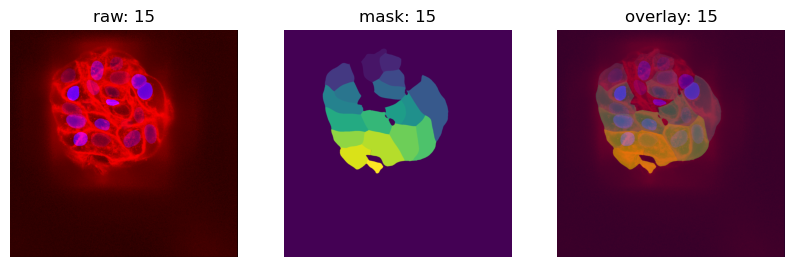

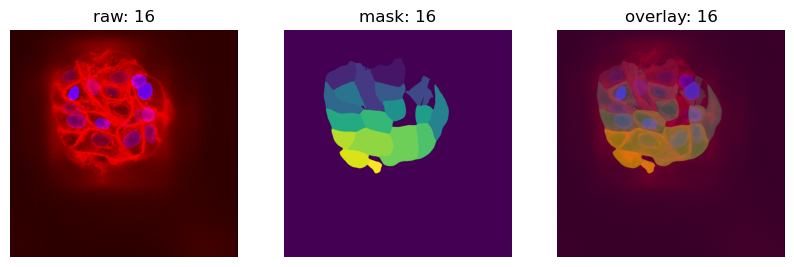

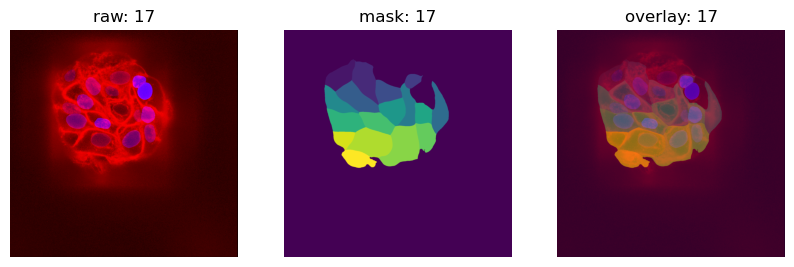

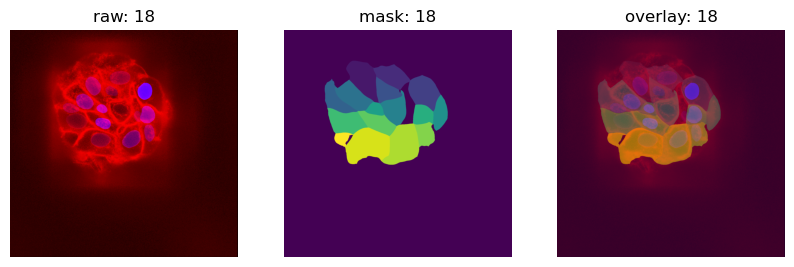

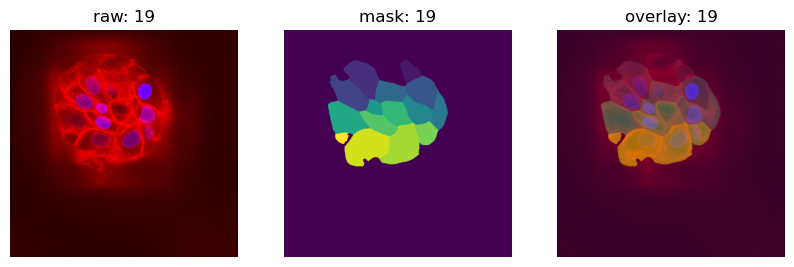

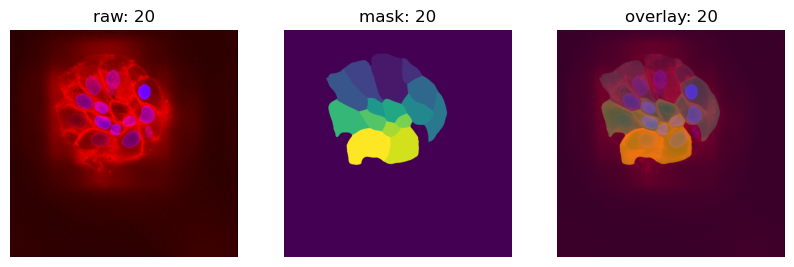

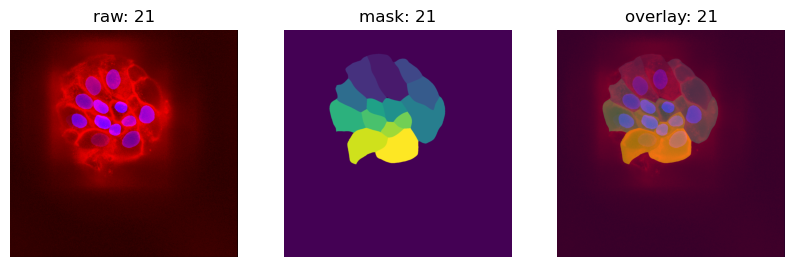

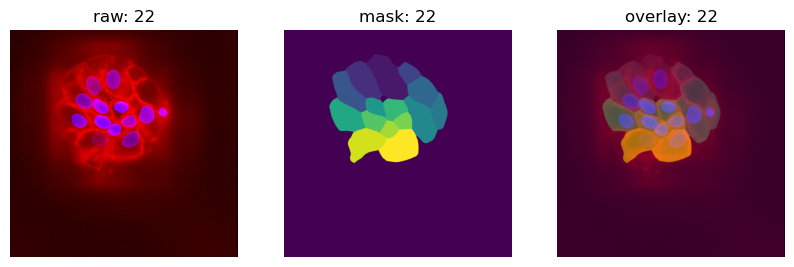

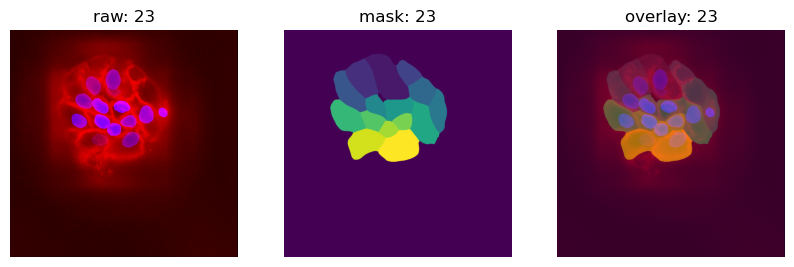

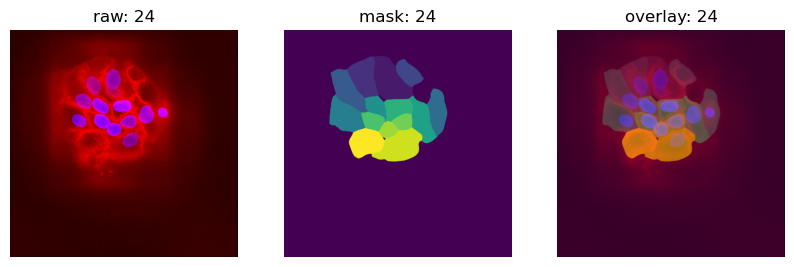

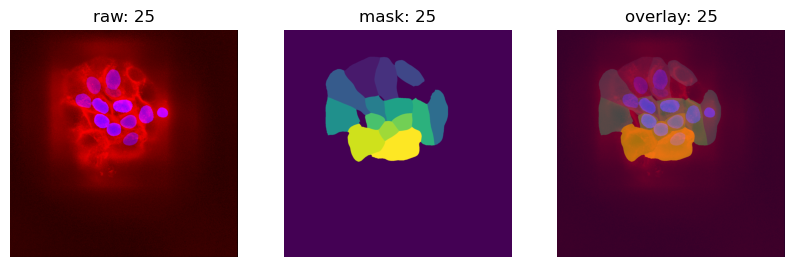

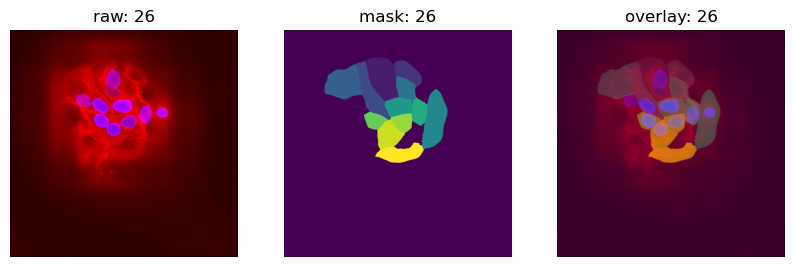

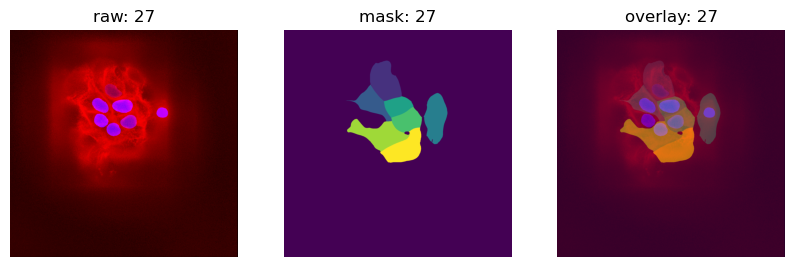

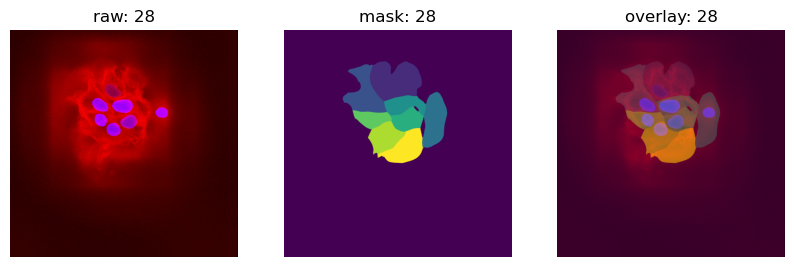

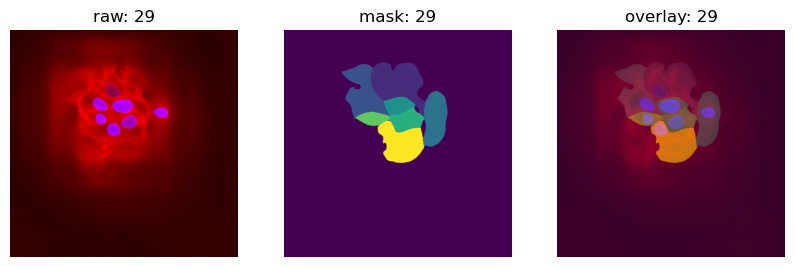

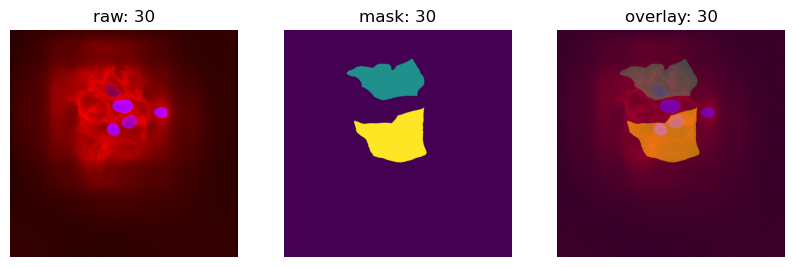

In [11]:
if in_notebook:
    plot = plt.figure(figsize=(10, 5))
    for z in range(len(masks_all)):
        plt.figure(figsize=(10, 10))
        plt.subplot(131)
        plt.imshow(imgs[z], cmap="gray")
        plt.title(f"raw: {z}")
        plt.axis("off")

        plt.subplot(132)
        plt.imshow(masks_all[z])
        plt.title(f"mask: {z}")
        plt.axis("off")

        plt.subplot(133)
        plt.imshow(imgs[z])
        plt.imshow(masks_all[z], alpha=0.5)
        plt.title(f"overlay: {z}")
        plt.axis("off")
        plt.show()